11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


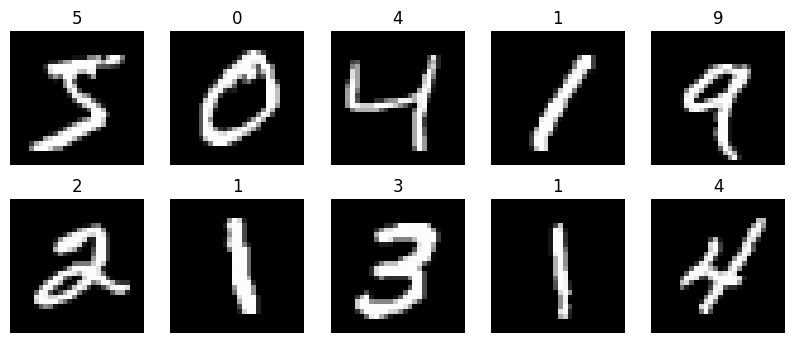

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9226 - loss: 0.2681 - val_accuracy: 0.9542 - val_loss: 0.1493
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9658 - loss: 0.1150 - val_accuracy: 0.9675 - val_loss: 0.1052
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9761 - loss: 0.0773 - val_accuracy: 0.9714 - val_loss: 0.0976
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9810 - loss: 0.0594 - val_accuracy: 0.9700 - val_loss: 0.0973
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9858 - loss: 0.0448 - val_accuracy: 0.9721 - val_loss: 0.0991


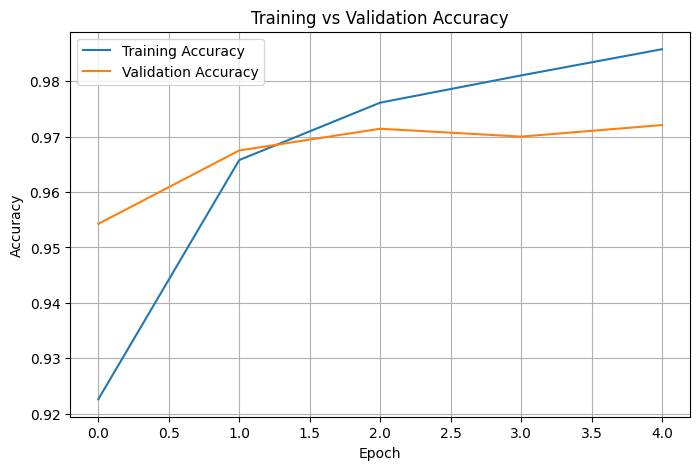

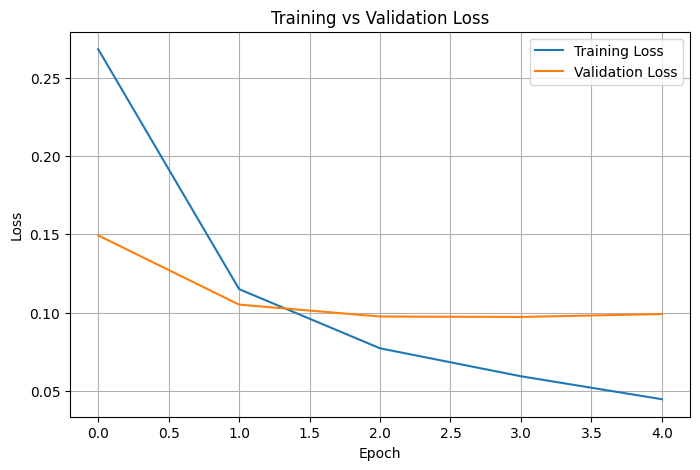

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9720 - loss: 0.0927

Test Loss : 0.0927276685833931
Test Accuracy : 0.972000002861023
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


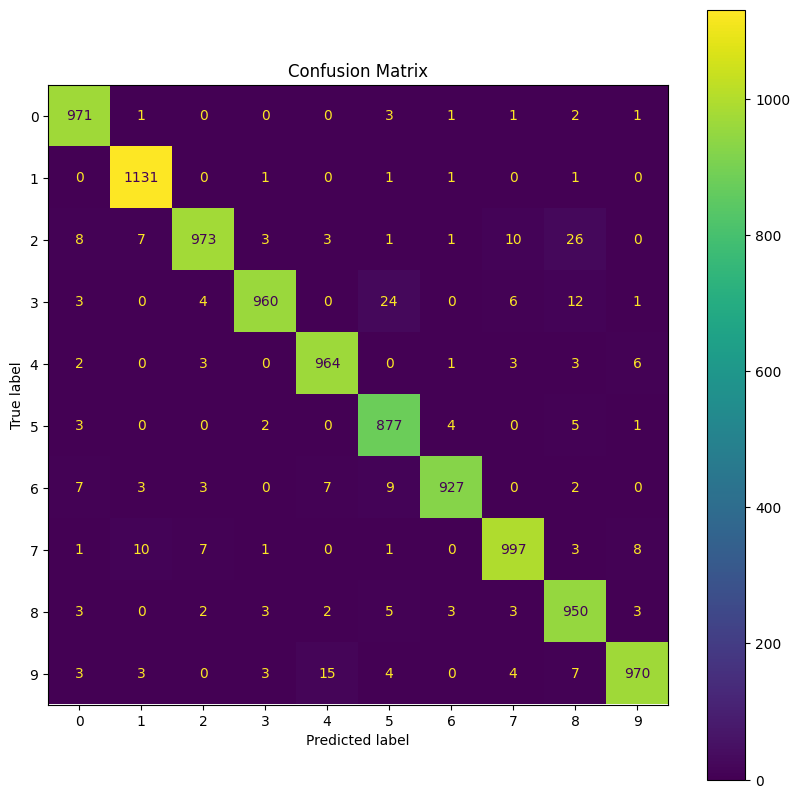

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      1.00      0.99      1135
           2       0.98      0.94      0.96      1032
           3       0.99      0.95      0.97      1010
           4       0.97      0.98      0.98       982
           5       0.95      0.98      0.97       892
           6       0.99      0.97      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.94      0.98      0.96       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



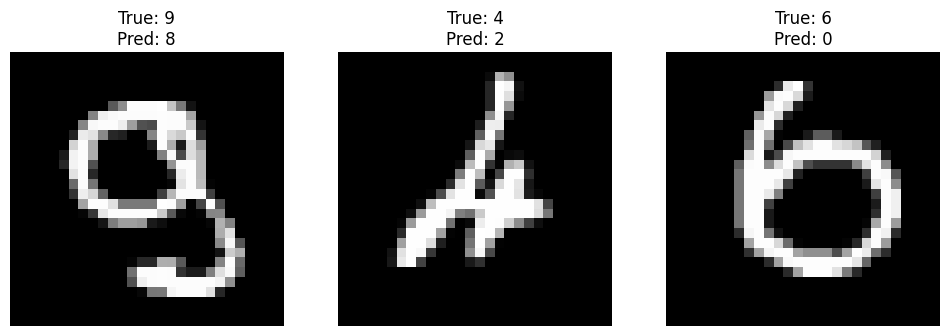

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Images:", x_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images :", x_test.shape)
print("Testing Labels :", y_test.shape)

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

model = tf.keras.Sequential([

    tf.keras.layers.Flatten(input_shape=(28,28)),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )

])

model.summary()

model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

history = model.fit(

    x_train,
    y_train,

    validation_split=0.2,

    epochs=5,

    batch_size=32,

    verbose=1

)

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

loss, accuracy = model.evaluate(x_test, y_test)

print("\nTest Loss :", loss)
print("Test Accuracy :", accuracy)

predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(
    y_test,
    predicted_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

fig, ax = plt.subplots(figsize=(10,10))

disp.plot(ax=ax)

plt.title("Confusion Matrix")

plt.show()

print(classification_report(
    y_test,
    predicted_labels
))

misclassified = np.where(predicted_labels != y_test)[0]

plt.figure(figsize=(12,4))

for i in range(3):

    index = misclassified[i]

    plt.subplot(1,3,i+1)

    plt.imshow(x_test[index], cmap="gray")

    plt.title(
        f"True: {y_test[index]}\nPred: {predicted_labels[index]}"
    )

    plt.axis("off")

plt.show()